# Explore one real HEST sample

This notebook is a quick, hands-on way to inspect one real sample from the HEST-1k dataset.

What we are doing here:
- inspect the sample metadata
- download a small subset of files for one sample
- look at one real tissue patch and its gene expression values

We are not downloading the full dataset, and no pipelines are built yet. More systematic analysis will be done later.

HEST comes with a `hest` Python package to process the data. However, we will access the dataset from Hugging Face directly and read the files with common tools such as `pandas`, `anndata`, `h5py`, `PIL`, and `matplotlib`.

In [2]:
%pip install -q huggingface_hub pandas anndata h5py pillow matplotlib

Note: you may need to restart the kernel to use updated packages.


## Step 1: log in to Hugging Face

This notebook accesses a gated dataset on Hugging Face, so the login step is required so the library can authenticate your access.

Complete the following before proceeding:
- request the dataset access request on Hugging Face; it will be automatically accepted
- acquire a read-only token for your account from https://huggingface.co/settings/tokens

There are two ways to log in:
- store your token in a local `.env` file as `HF_TOKEN`, and that is enough for Hugging Face to recognize you
- enter your token when prompted in the `login()` call

Caution: ***Never*** paste the token into an AI chat, and ***never*** upload it to github. Only use it in the login prompt or in a local `.env` file

In [3]:
from huggingface_hub import login, whoami
from dotenv import load_dotenv
import os

load_dotenv()  # auto-detects .env location
# if huggingface token is not present in env, then prompt for one
if not os.getenv("HF_TOKEN"):
    login()

whoami()  # should output user info

{'type': 'user',
 'id': '6ab4394a4d67ecbb19663599',
 'name': 'Accord985',
 'fullname': 'Siyu Wang',
 'email': 'bwang120@jh.edu',
 'emailVerified': True,
 'canPay': False,
 'billingMode': 'prepaid',
 'periodEnd': 1793491200,
 'isPro': False,
 'avatarUrl': 'https://cdn-avatars.huggingface.co/v1/production/uploads/no-auth/pPg2Lk8db_dtGTm6Y_XM2.png',
 'orgs': [],
 'auth': {'type': 'access_token',
  'accessToken': {'displayName': 'hest',
   'role': 'read',
   'createdAt': '2026-09-29T19:25:24.259Z'}}}

## Step 2: inspect the metadata table

The dataset includes a metadata table. There is a metatable for each version of the dataset, and table for the latest version is called `HEST_v1_3_0.csv`. That file tells us a ton of useful information including:
- `id`
- `organ`
- `species`
- `st_technology` - stain technology
- `oncotree_code` - a unique code for different cancer types

After printing the table, we can pick one sample ID, and then download and inspect the data tied to it.

In [4]:
from huggingface_hub import hf_hub_download
import pandas as pd

# hf_hub_download downloads only one file, stores in a cache somewhere,
# and returns the path to the downloaded file
meta_path = hf_hub_download(
    repo_id="MahmoodLab/hest",
    repo_type="dataset",
    filename="HEST_v1_3_0.csv",
)
meta = pd.read_csv(meta_path)
print("meta shape:", meta.shape)
display(meta[['id', 'organ', 'species', 'st_technology', 'oncotree_code']].head(20))

meta shape: (1276, 28)


,id,organ,species,st_technology,oncotree_code
0,TENX202,Breast,Homo sapiens,Xenium,IDC
1,TENX201,Breast,Homo sapiens,Xenium,IDC
2,TENX200,Breast,Homo sapiens,Xenium,IDC
3,TENX199,Breast,Homo sapiens,Xenium,IDC
4,TENX198,Breast,Homo sapiens,Xenium,IDC
5,TENX197,Breast,Homo sapiens,Xenium,IDC
6,TENX196,Breast,Homo sapiens,Xenium,IDC
7,TENX195,Breast,Homo sapiens,Xenium,IDC
8,TENX194,Breast,Homo sapiens,Xenium,NaN
9,TENX193,Breast,Homo sapiens,Xenium,IDC


We are interested in samples of breasts:

In [5]:
# Adjust this filter to match your project's cohort
meta[meta['organ'].str.contains('Breast', case=False, na=False)][['id', 'organ', 'species', 'st_technology']]

,id,organ,species,st_technology
0,TENX202,Breast,Homo sapiens,Xenium
1,TENX201,Breast,Homo sapiens,Xenium
2,TENX200,Breast,Homo sapiens,Xenium
3,TENX199,Breast,Homo sapiens,Xenium
4,TENX198,Breast,Homo sapiens,Xenium
...,...,...,...,...
420,SPA0,Breast,Homo sapiens,Spatial Transcriptomics
612,NCBI785,Breast,Homo sapiens,Xenium
613,NCBI784,Breast,Homo sapiens,Xenium
614,NCBI783,Breast,Homo sapiens,Xenium


## Step 3: download one sample

This project contains many samples and large files, such as the large whole-slide images (stored `wsis/` in the dataset repo). We don't need those. To keep things manageable, we only download the files needed for one sample.

This should take well under a minute.

Caution: ***Do not*** upload the downloaded data to github. They are large, and people can easily get them by themselves.

Note: From now on there are file loading and saving operations. **The notebook assumes that it is located in a folder `notebooks/` with its parent directory being the project root.**

In [ ]:
import glob
from huggingface_hub import snapshot_download

sample_id = "TENX95"  # <-- swap in an id from the table above
data_dir = "data"  # <-- folder name of local directory, will be in project root, make sure it is in gitignore

# snapshot_download downloads multiple files in a repo
# whose directory pattern inside the repo matches a pattern
# and then stores them in a local directory while keeping subdirectory structure
snapshot_download(
    repo_id="MahmoodLab/hest",
    repo_type="dataset",
    local_dir=f"../{data_dir}",
    allow_patterns=[
        f"spatial_plots/*{sample_id}*",
        f"thumbnails/*{sample_id}*",
        f"st/*{sample_id}*",
        f"patches/*{sample_id}*",
    ],
)

# Show a quick confirmation that the relevant files were downloaded.
print(glob.glob(f"../{data_dir}/**/*{sample_id}*", recursive=True))

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

patches/TENX202.h5:   0%|          | 0.00/664M [00:00<?, ?B/s]

thumbnails/TENX202_downscaled_fullres.jp(…):   0%|          | 0.00/327k [00:00<?, ?B/s]

spatial_plots/TENX202_spatial_plots.png:   0%|          | 0.00/3.04M [00:00<?, ?B/s]

st/TENX202.h5ad:   0%|          | 0.00/15.2M [00:00<?, ?B/s]

['../data\\patches\\TENX202.h5', '../data\\spatial_plots\\TENX202_spatial_plots.png', '../data\\st\\TENX202.h5ad', '../data\\thumbnails\\TENX202_downscaled_fullres.jpeg']


## Step 4: Inspect the data

### Part I: view the dataset's built-in spatial map

HEST includes a ready-made spatial image for each sample (`/spatial_plots`). It shows the a complete image of the tissue overlaid with capture spots locations.

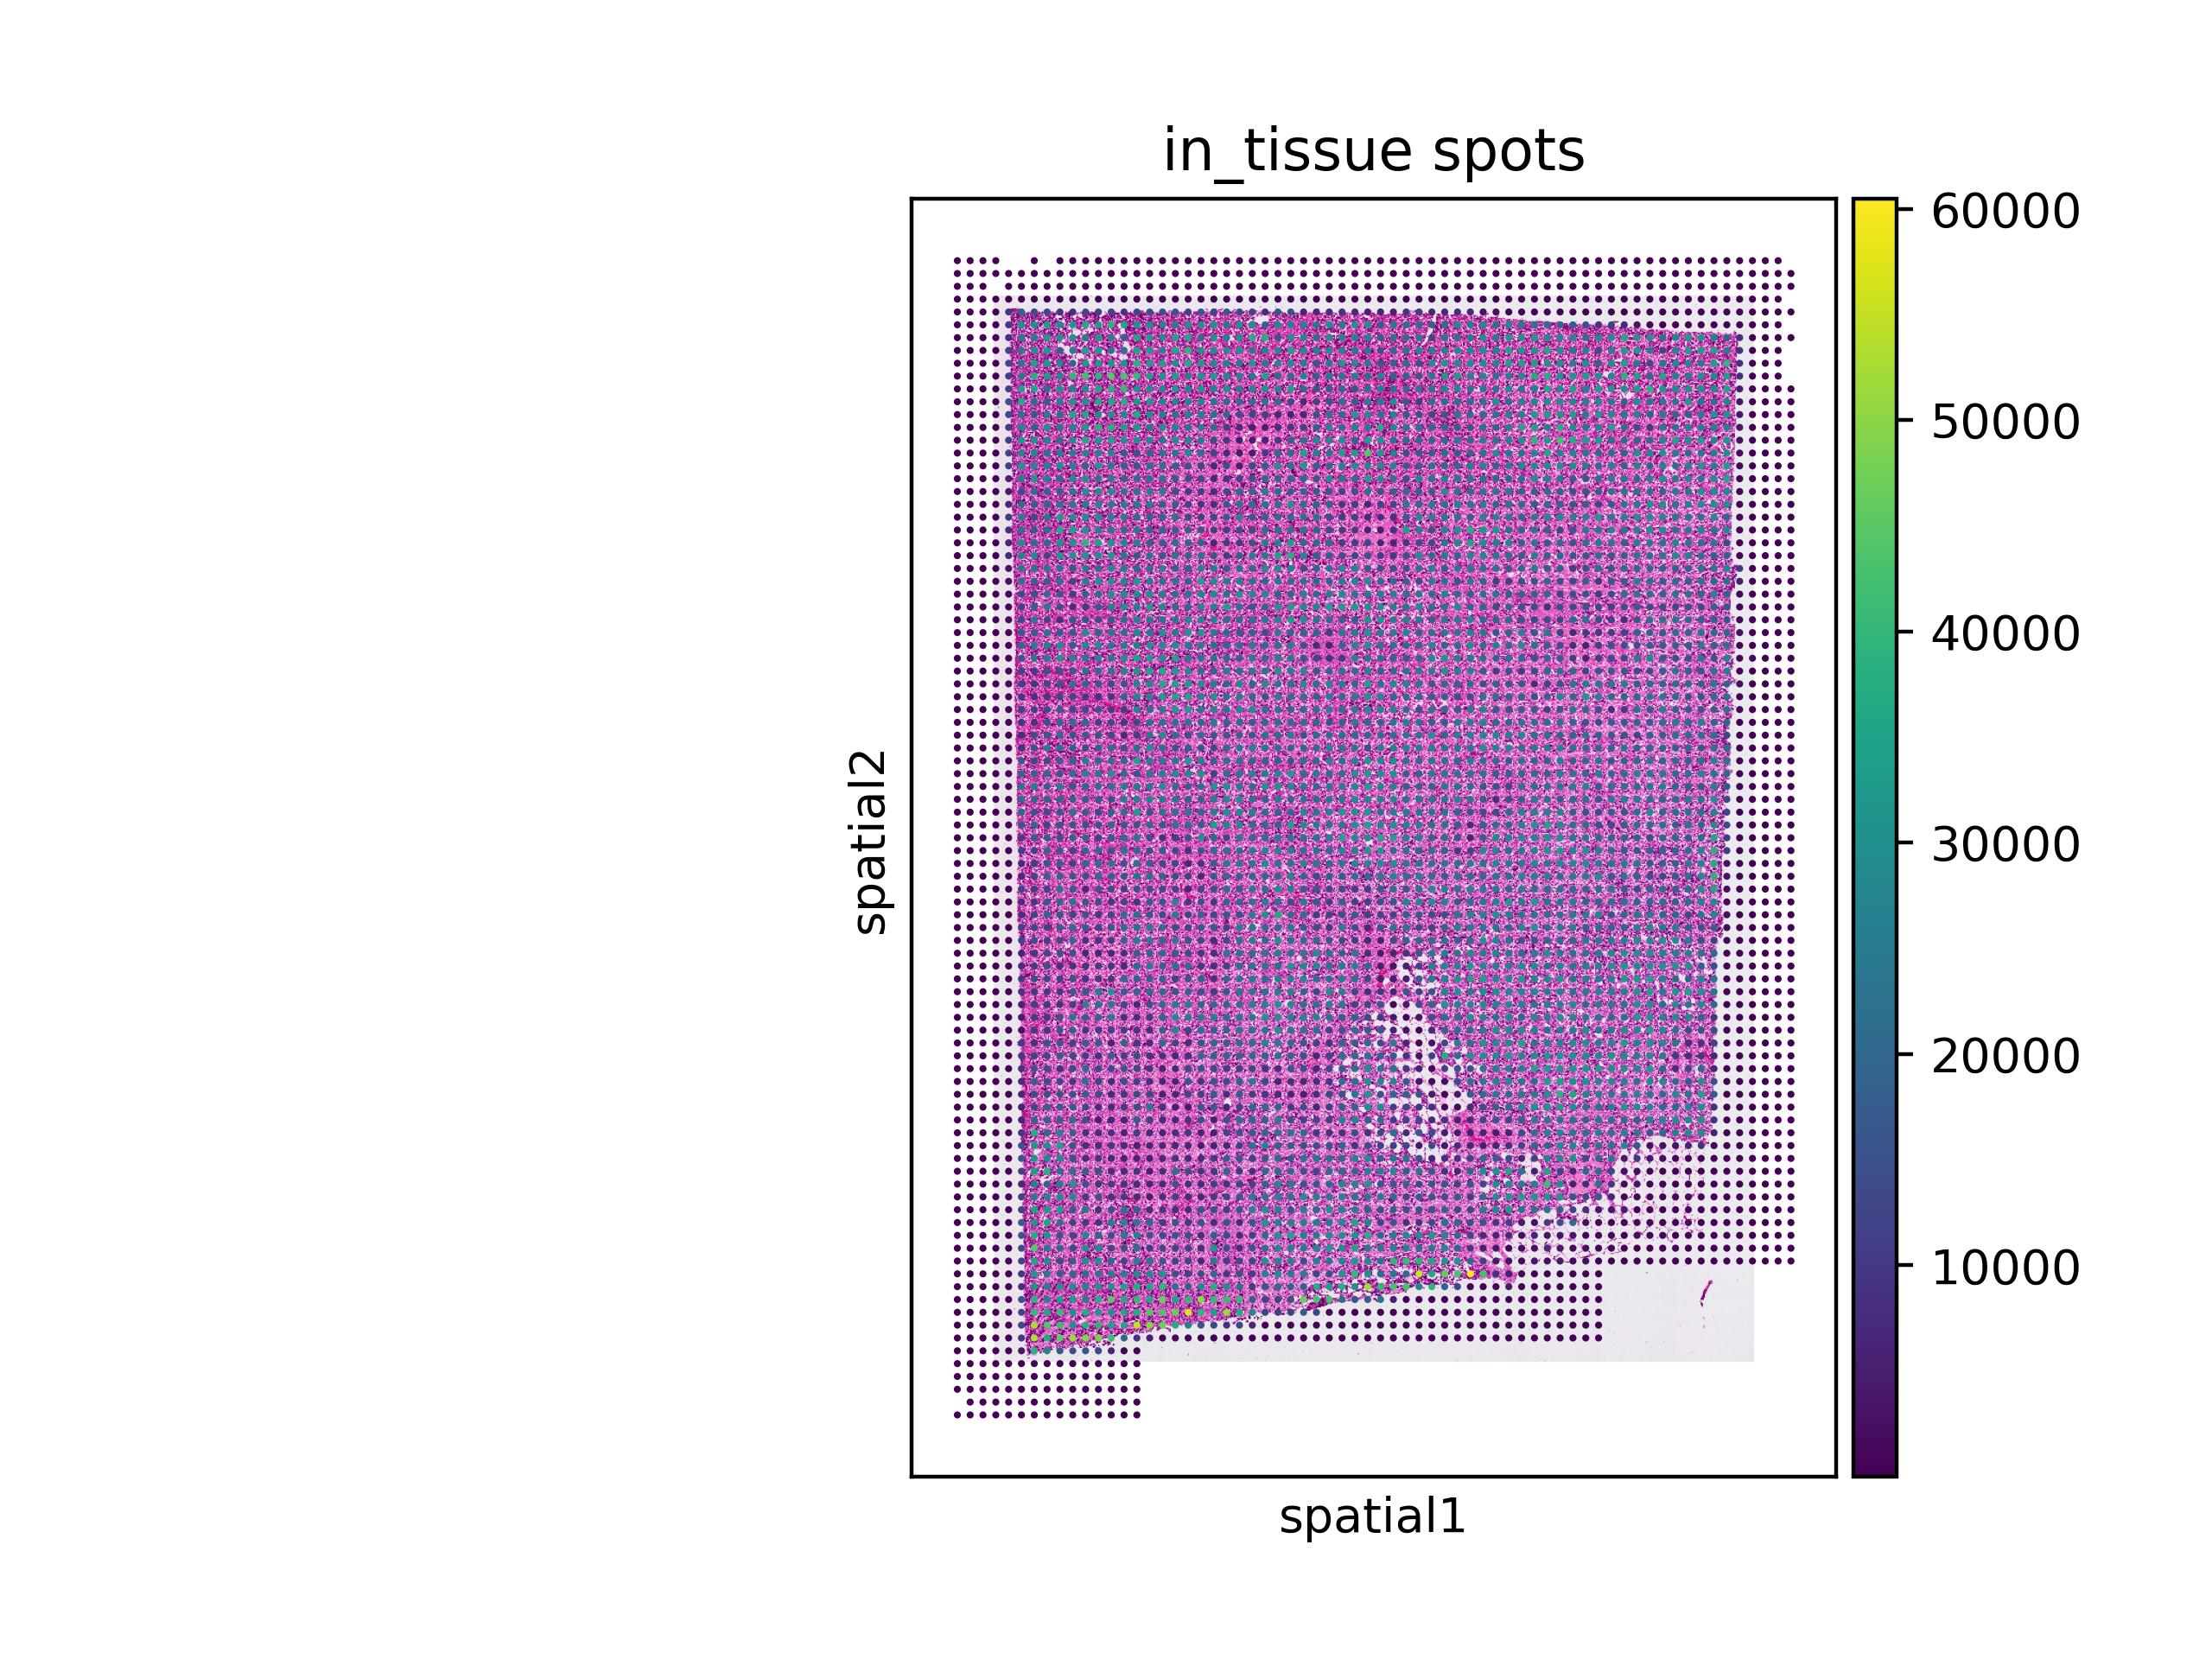

In [7]:
from PIL import Image

img_path = glob.glob(f"../{data_dir}/spatial_plots/*{sample_id}*")[0]
Image.open(img_path)

### Part II: compare the tissue to its gene expression

In the overlay image, a patch is defined as a 224x224 area around a spot. In this part, we connect the patch data (`/patches`) to its gene expression data (`st/`).

This gives a direct example of how the dataset links:
- spatial location
- image patch
- gene expression at that same location

*Notes: The dataset stores patch information in `.h5` file and gene expression data in `.h5ad` format. To gain a basic understanding of `.h5`, `.h5ad`, and the packages to deal with them (`h5py` and `anndata`, respectively), please ask an AI for a quick example.*

In [8]:
# sanity check: make sure the dataset names in the file exist
# before we index into it

import h5py

patches_path = glob.glob(f"../{data_dir}/patches/*{sample_id}*")[0]
with h5py.File(patches_path, "r") as f:
    print(list(f.keys()))

['barcode', 'coords', 'img']


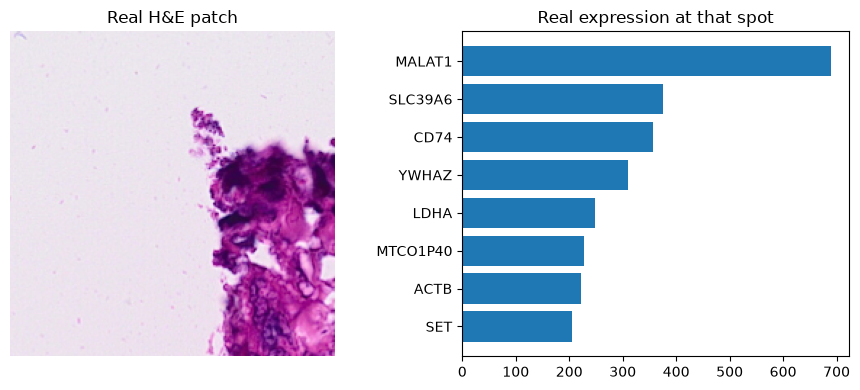

In [9]:
import anndata
import numpy as np
import matplotlib.pyplot as plt

adata = anndata.read_h5ad(glob.glob(f"../{data_dir}/st/*{sample_id}*")[0])

with h5py.File(patches_path, "r") as f:
    imgs = f["img"][:]
    raw_barcodes = f["barcode"][:]
    barcodes = []
    for b in raw_barcodes:
        if hasattr(b, "ravel"):
            b = b.ravel()[0]
        if isinstance(b, bytes):
            b = b.decode()
        barcodes.append(b)

i = 0
patch = imgs[i]
row = adata[adata.obs_names == barcodes[i]] if barcodes[i] in adata.obs_names else adata[i]

expr = row.X.toarray().ravel() if hasattr(row.X, "toarray") else np.asarray(row.X).ravel()
top = np.argsort(expr)[-8:][::-1]

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(patch)
axes[0].axis("off")
axes[0].set_title("Real H&E patch")
axes[1].barh(row.var_names[top][::-1], expr[top][::-1])
axes[1].set_title("Real expression at that spot")
plt.tight_layout()
plt.show()

## Step 5: Save the results

Now it is time to store our results. We will take the original spatial plot as well as one patch-expression pair and store them in a separate `outputs/` folder.

Caution: ***Do not*** upload the outputs to github because again they can get large and can easily be reproduced.

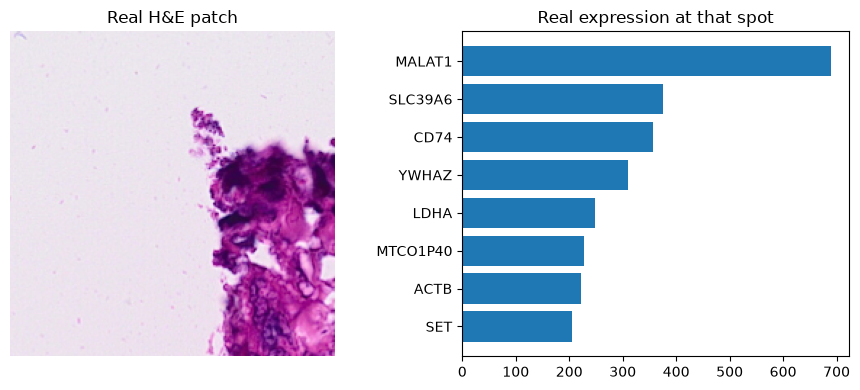

In [ ]:
import glob, shutil
import h5py, anndata, numpy as np
import matplotlib.pyplot as plt

outputs_dir = "outputs"  # <- make sure it's in gitignore

# 1. Copy the premade spatial overlay to a clean filename
overview_src = glob.glob(f"../{data_dir}/spatial_plots/*{sample_id}*")[0]
shutil.copy(overview_src, f"../{outputs_dir}/spatial_overview.png")

# 2. Rebuild the patch + expression chart at high resolution
# code for plot creation copied from the cell above
adata = anndata.read_h5ad(glob.glob(f"../{data_dir}/st/*{sample_id}*")[0])
patches_path = glob.glob(f"../{data_dir}/patches/*{sample_id}*")[0]

with h5py.File(patches_path, "r") as f:
    imgs = f["img"][:]
    raw_barcodes = f["barcode"][:]
    barcodes = []
    for b in raw_barcodes:
        if hasattr(b, "ravel"):
            b = b.ravel()[0]
        if isinstance(b, bytes):
            b = b.decode()
        barcodes.append(b)

i = 0
patch = imgs[i]
row = adata[adata.obs_names == barcodes[i]] if barcodes[i] in adata.obs_names else adata[i]
expr = row.X.toarray().ravel() if hasattr(row.X, "toarray") else np.asarray(row.X).ravel()
top = np.argsort(expr)[-8:][::-1]

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(patch); axes[0].axis("off"); axes[0].set_title("A H&E patch")
axes[1].barh(row.var_names[top][::-1], expr[top][::-1]); axes[1].set_title("The expression at that spot")
plt.tight_layout()
plt.savefig(f"../{outputs_dir}/patch_expr.png", dpi=200, bbox_inches="tight")
plt.show()

You are good to go! But if you are using Google Colab, you will need this to download the saved results to your local machine:

In [11]:
from google.colab import files
files.download(f"../{outputs_dir}/spatial_overview.png")
files.download(f"../{outputs_dir}/patch_expr.png")

ModuleNotFoundError: No module named 'google'

---


### The code did not work?

If the spatial plot keys do not exactly match `"img"` and `"barcode"`, that is usually the only part that needs adjustment. The rest of the notebook depends on the files you have already downloaded and should work the same way once the file structure is confirmed. Also make sure the notebook is placed in the right place; the document structure should look like this:

<pre>
Hist2ST/
├── README.md
├── data/
├── outputs/
├── notebooks/
│   └── preview_one_hest_sample.ipynb
├── ...
</pre>